In [16]:
import pandas as pd

In [17]:
df = pd.read_excel("../data/raw/online_retail_II.xlsx")


In [18]:
df.shape

(525461, 8)

In [19]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [20]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

In [21]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(6865)

In [23]:
df[df.duplicated()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


In [24]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [25]:
(df["Quantity"] < 0).sum()

np.int64(12326)

In [26]:
df[df["Invoice"].astype(str).str.startswith("C")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [27]:
df[df["Price"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [28]:
(df["Price"] < 0).sum()

np.int64(3)

In [29]:
df[df["Quantity"] > 1000][
    ["Invoice", "StockCode", "Description", "Quantity", "Price", "Country"]
].sort_values("Quantity", ascending=False).head(10)

,Invoice,StockCode,Description,Quantity,Price,Country
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,Denmark
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,0.10,Denmark
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,0.10,Denmark
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,0.10,Denmark
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,0.10,Denmark
192197,507637,84016,FLAG OF ST GEORGE CAR FLAG,10200,0.00,United Kingdom
135027,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,0.25,United Kingdom
135029,502269,21980,PACK OF 12 RED SPOTTY TISSUES,10000,0.25,United Kingdom
135030,502269,21981,PACK OF 12 WOODLAND TISSUES,10000,0.25,United Kingdom
135028,502269,21982,PACK OF 12 SUKI TISSUES,10000,0.25,United Kingdom


In [30]:
df["Country"].nunique()


40

In [31]:
df["Country"].value_counts().head(10)

Country
United Kingdom     485852
EIRE                 9670
Germany              8129
France               5772
Netherlands          2769
Spain                1278
Switzerland          1187
Portugal             1101
Belgium              1054
Channel Islands       906
Name: count, dtype: int64

In [32]:
df["StockCode"].nunique()

4632

In [33]:
df["Customer ID"].nunique()

4383

In [34]:
df["Description"].isna().sum()

np.int64(2928)

In [35]:
df_clean = df.drop_duplicates()

In [36]:
df_clean.shape

(518596, 8)

In [37]:
df_clean[df_clean["Description"].isna()][
    ["StockCode", "Quantity", "Price", "Customer ID", "Country"]
].head(10)

,StockCode,Quantity,Price,Customer ID,Country
470,21646,-50,0.0,NaN,United Kingdom
3114,20683,-44,0.0,NaN,United Kingdom
3161,21350,230,0.0,NaN,United Kingdom
3731,84292,17,0.0,NaN,United Kingdom
4296,18010,-770,0.0,NaN,United Kingdom
4566,85049G,-240,0.0,NaN,United Kingdom
6378,35751C,12,0.0,NaN,United Kingdom
6555,79323G,954,0.0,NaN,United Kingdom
6576,21098,-200,0.0,NaN,United Kingdom
6581,21166,48,0.0,NaN,United Kingdom


In [38]:
df_clean[df_clean["Customer ID"].isna()][
    ["Invoice", "StockCode", "Description", "Quantity", "Price", "Country"]
].head(10)

,Invoice,StockCode,Description,Quantity,Price,Country
263,489464,21733,85123a mixed,-96,0.00,United Kingdom
283,489463,71477,short,-240,0.00,United Kingdom
284,489467,85123A,21733 mixed,-192,0.00,United Kingdom
470,489521,21646,NaN,-50,0.00,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,0.55,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,0.85,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2.95,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,1.25,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2.95,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,1.65,United Kingdom


In [39]:
(df_clean["Price"] == 0).sum()

np.int64(3681)

In [40]:
df_clean[df_clean["Price"] == 0][
    ["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID", "Country"]
].head(20)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,0.0,NaN,United Kingdom
283,489463,71477,short,-240,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,0.0,NaN,United Kingdom


In [41]:
df_clean.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107833
Country             0
dtype: int64

In [42]:
df_clean["Invoice"].astype(str).str.startswith("C").sum()

np.int64(10182)

In [43]:

df_clean["IsCancelled"] = df_clean["Invoice"].astype(str).str.startswith("C")


In [44]:
df_clean["IsCancelled"].value_counts()

IsCancelled
False    508414
True      10182
Name: count, dtype: int64

In [45]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["Price"]

In [46]:
df_clean[["Quantity", "Price", "Revenue"]].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [47]:
country_revenue = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    8161692.763
EIRE               352235.680
Netherlands        263861.760
Germany            195920.421
France             130661.550
Sweden              51190.110
Denmark             46972.950
Switzerland         43343.410
Spain               37052.130
Australia           30051.800
Name: Revenue, dtype: float64

In [48]:
country_revenue = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    8161692.763
EIRE               352235.680
Netherlands        263861.760
Germany            195920.421
France             130661.550
Sweden              51190.110
Denmark             46972.950
Switzerland         43343.410
Spain               37052.130
Australia           30051.800
Name: Revenue, dtype: float64

In [49]:
df_clean[df_clean["IsCancelled"] == True][
    ["Invoice", "Quantity", "Price", "Revenue"]
].head(10)

,Invoice,Quantity,Price,Revenue
178,C489449,-12,2.95,-35.40
179,C489449,-6,1.65,-9.90
180,C489449,-4,4.25,-17.00
181,C489449,-6,2.10,-12.60
182,C489449,-12,2.95,-35.40
183,C489449,-12,1.25,-15.00
184,C489449,-12,1.25,-15.00
185,C489449,-24,0.85,-20.40
186,C489449,-12,2.95,-35.40
196,C489459,-3,4.25,-12.75


In [50]:
df_clean["Revenue"].sum()

np.float64(9505775.564)

In [51]:
positive_revenue = df_clean.loc[df_clean["Revenue"] > 0, "Revenue"].sum()
positive_revenue

np.float64(10272136.234)

In [52]:
negative_revenue = df_clean.loc[df_clean["Revenue"] < 0, "Revenue"].sum()
negative_revenue

np.float64(-766360.6699999999)

In [53]:
cancelled_revenue = df_clean.loc[
    df_clean["IsCancelled"] == True, "Revenue"
].sum()

cancelled_revenue

np.float64(-629435.08)

In [54]:
cancellation_rate = (
    df_clean["IsCancelled"].sum() / len(df_clean)
) * 100

cancellation_rate

np.float64(1.96337804379517)

In [55]:
import matplotlib.pyplot as plt

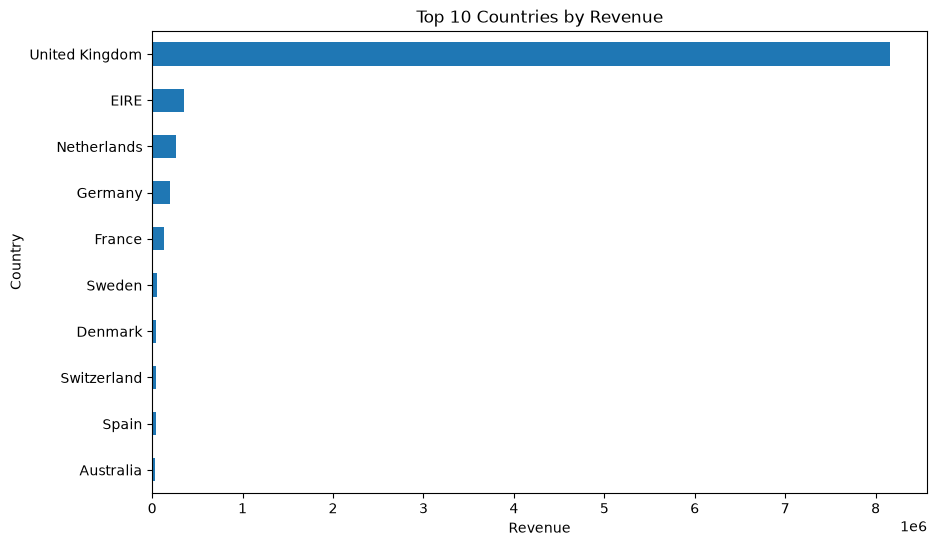

In [56]:
country_revenue.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

In [57]:
avg_revenue_country = (
    df_clean.groupby("Country")["Revenue"]
    .mean()
    .sort_values(ascending=False)
)

avg_revenue_country.head(10)

Country
Denmark        109.749883
Netherlands     95.325780
Sweden          56.814772
Hong Kong       51.608684
Australia       45.950765
Israel          43.235135
Thailand        40.401842
Japan           37.660536
Bermuda         36.857059
Switzerland     36.515088
Name: Revenue, dtype: float64

In [58]:
country_stats = df_clean.groupby("Country").agg(
    Transactions=("Invoice", "count"),
    Total_Revenue=("Revenue", "sum"),
    Average_Revenue=("Revenue", "mean")
).sort_values("Total_Revenue", ascending=False)

country_stats.head(10)

,Transactions,Total_Revenue,Average_Revenue
Country,,,
United Kingdom,479047,8161692.763,17.037353
EIRE,9660,352235.680,36.463321
Netherlands,2768,263861.760,95.325780
Germany,8120,195920.421,24.128131
France,5754,130661.550,22.707951
Sweden,901,51190.110,56.814772
Denmark,428,46972.950,109.749883
Switzerland,1187,43343.410,36.515088
Spain,1271,37052.130,29.151951


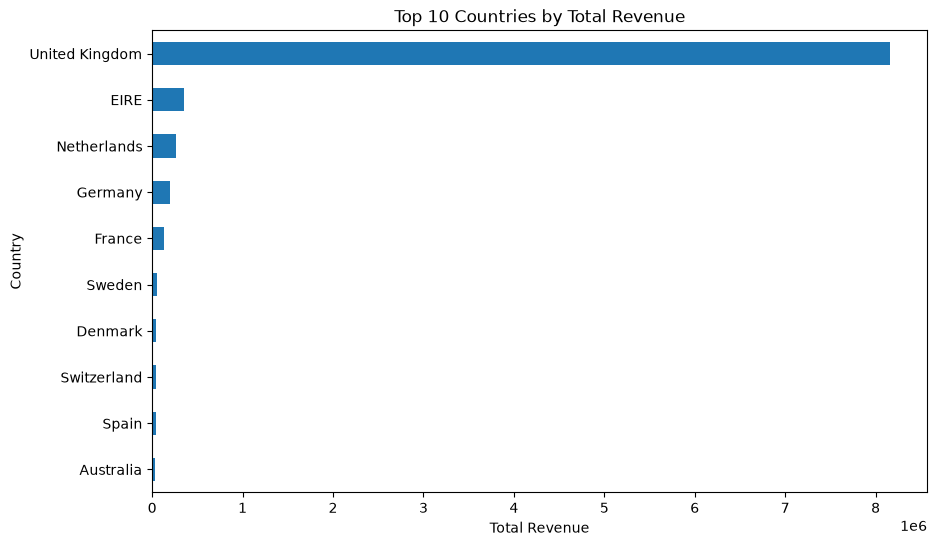

In [59]:
country_stats.head(10)["Total_Revenue"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Countries by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.show()

In [60]:
product_revenue = (
    df_clean.groupby("StockCode")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)

StockCode
22423     162885.71
85123A    155540.37
DOT       116401.99
85099B     88784.03
84879      72251.32
22086      57808.25
47566      49626.92
84347      47641.89
POST       46092.36
21843      42073.15
Name: Revenue, dtype: float64

In [61]:
top_products = product_revenue.head(10).index

top_product_details = df_clean[
    df_clean["StockCode"].isin(top_products)
][["StockCode", "Description"]].drop_duplicates()

top_product_details["StockCode"] = top_product_details["StockCode"].astype(str)

top_product_details.sort_values("StockCode")

,StockCode,Description
276226,21843,damaged
416039,21843,broken
146580,21843,RED RETROSPOT CAKE STAND
2086,21843,RETRO SPOT CAKE STAND
151,22086,PAPER CHAIN KIT 50'S CHRISTMAS
280027,22086,NaN
213344,22423,NaN
124243,22423,REGENCY CAKESTAND 3 TIER
192773,22423,smashed
524286,22423,faulty


In [62]:
product_names = (
    df_clean[df_clean["Description"].notna()]
    .groupby("StockCode")["Description"]
    .agg(lambda x: x.value_counts().index[0])
)

top_product_names = product_names.reindex(product_revenue.head(10).index)

top_product_names

StockCode
22423                REGENCY CAKESTAND 3 TIER
85123A     WHITE HANGING HEART T-LIGHT HOLDER
DOT                            DOTCOM POSTAGE
85099B                JUMBO BAG RED RETROSPOT
84879           ASSORTED COLOUR BIRD ORNAMENT
22086         PAPER CHAIN KIT 50'S CHRISTMAS 
47566                           PARTY BUNTING
84347     ROTATING SILVER ANGELS T-LIGHT HLDR
POST                                  POSTAGE
21843                RED RETROSPOT CAKE STAND
Name: Description, dtype: str

In [63]:
product_quantity = (
    df_clean[df_clean["Quantity"] > 0]
    .groupby("StockCode")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity.head(10)

StockCode
21212     60076
85123A    58387
84077     55058
85099B    49807
17003     48384
84879     45236
84991     36348
22197     33456
21977     31805
21232     27060
Name: Quantity, dtype: int64

In [64]:
product_quantity = (
    df_clean[df_clean["Quantity"] > 0]
    .groupby("StockCode")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity.head(10)

StockCode
21212     60076
85123A    58387
84077     55058
85099B    49807
17003     48384
84879     45236
84991     36348
22197     33456
21977     31805
21232     27060
Name: Quantity, dtype: int64

In [65]:
top_quantity_products = product_quantity.head(10).index

quantity_product_names = (
    df_clean[df_clean["Description"].notna()]
    .groupby("StockCode")["Description"]
    .agg(lambda x: x.value_counts().index[0])
)

quantity_product_names.reindex(top_quantity_products)

StockCode
21212       PACK OF 72 RETRO SPOT CAKE CASES
85123A    WHITE HANGING HEART T-LIGHT HOLDER
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS
85099B               JUMBO BAG RED RETROSPOT
17003                    BROCADE RING PURSE 
84879          ASSORTED COLOUR BIRD ORNAMENT
84991            60 TEATIME FAIRY CAKE CASES
22197                   SMALL POPCORN HOLDER
21977     PACK OF 60 PINK PAISLEY CAKE CASES
21232         STRAWBERRY CERAMIC TRINKET BOX
Name: Description, dtype: str

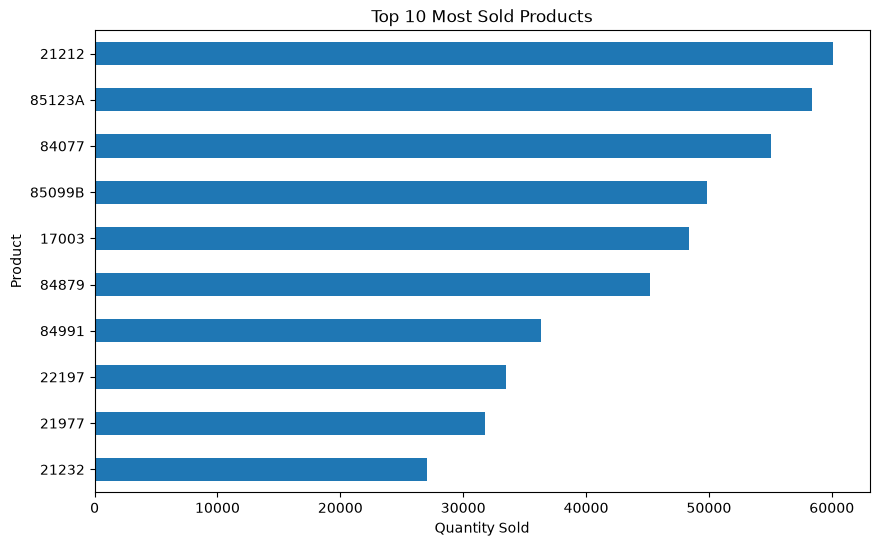

In [66]:

top_quantity = product_quantity.head(10).sort_values()

top_quantity.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Most Sold Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show() 

In [67]:
monthly_revenue = (
    df_clean
    .groupby(df_clean["InvoiceDate"].dt.to_period("M"))["Revenue"]
    .sum()
)

monthly_revenue.head()

InvoiceDate
2009-12    796648.500
2010-01    622479.502
2010-02    531265.366
2010-03    763247.241
2010-04    587926.692
Freq: M, Name: Revenue, dtype: float64

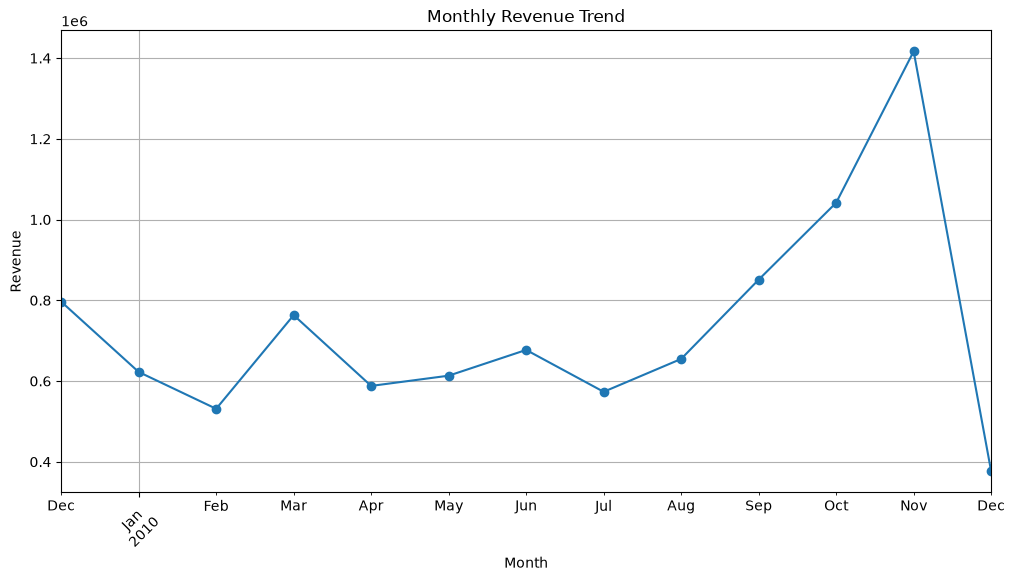

In [68]:
monthly_revenue.plot(
    kind="line",
    figsize=(12, 6),
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [69]:
customer_revenue = (
    df_clean[df_clean["Customer ID"].notna()]
    .groupby("Customer ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

Customer ID
18102.0    341776.73
14646.0    243853.05
14156.0    183163.55
14911.0    137710.76
13694.0    128172.42
17511.0     83760.60
15061.0     82162.74
16684.0     75610.17
13089.0     55801.73
16754.0     54558.18
Name: Revenue, dtype: float64

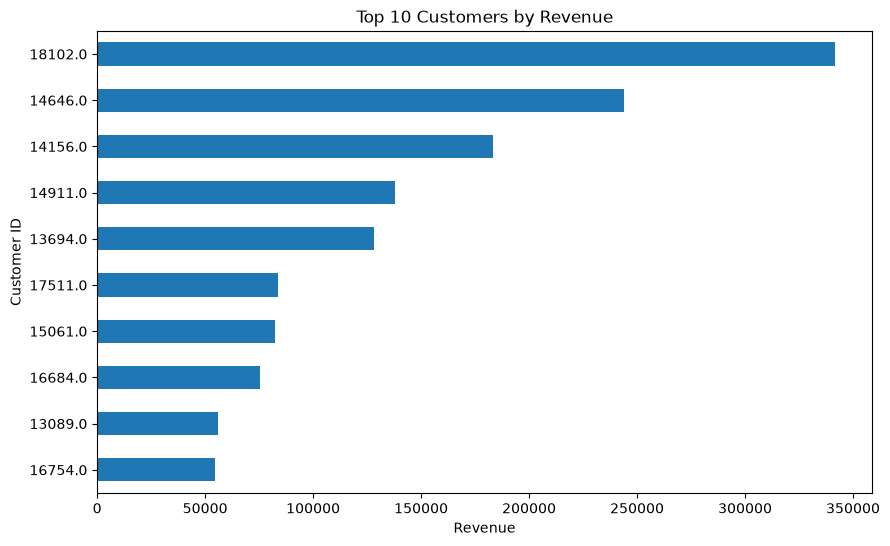

In [70]:
top_customers = customer_revenue.head(10).sort_values()

top_customers.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.show()

In [71]:
country_transactions = (
    df_clean.groupby("Country")["Invoice"]
    .count()
    .sort_values(ascending=False)
)

country_transactions.head(10)

Country
United Kingdom     479047
EIRE                 9660
Germany              8120
France               5754
Netherlands          2768
Spain                1271
Switzerland          1187
Portugal             1098
Belgium              1053
Channel Islands       906
Name: Invoice, dtype: int64

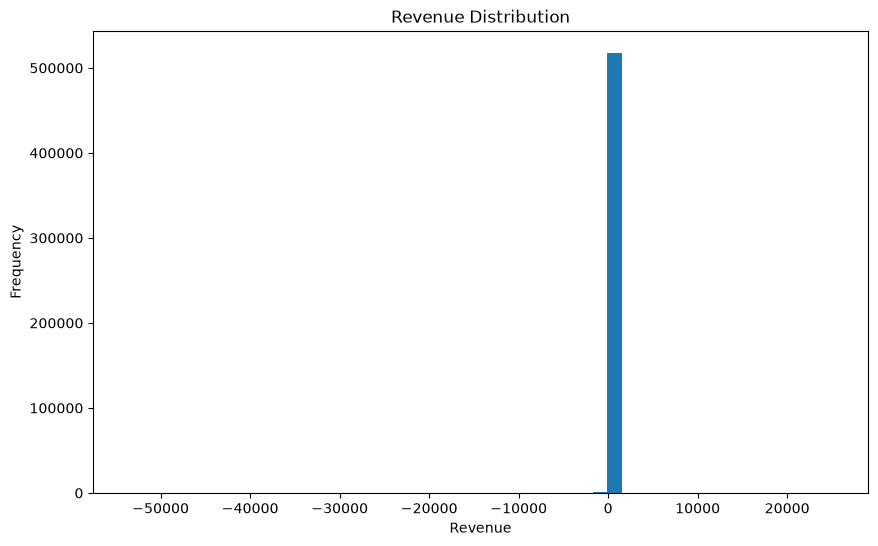

In [72]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["Revenue"], bins=50)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

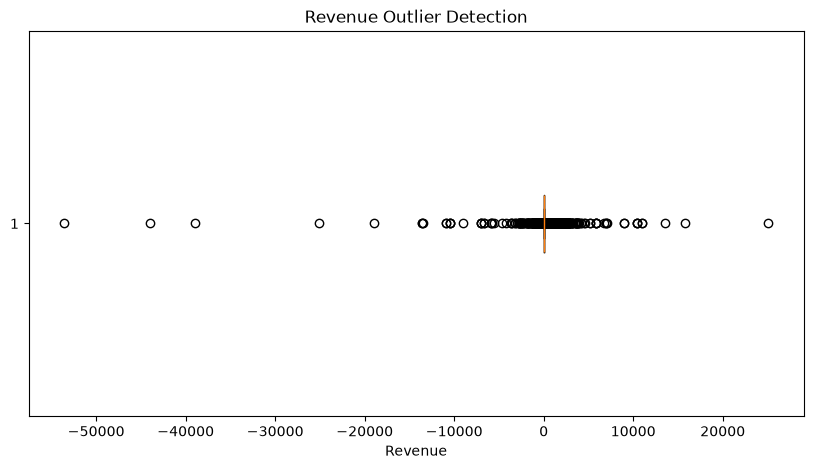

In [73]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    df_clean["Revenue"].dropna(),
    orientation="horizontal"
)

plt.title("Revenue Outlier Detection")
plt.xlabel("Revenue")

plt.show()

In [74]:
correlation = df_clean[
    ["Quantity", "Price", "Revenue", "Customer ID"]
].corr()

correlation

,Quantity,Price,Revenue,Customer ID
Quantity,1.000000,-0.001943,0.156200,-0.011225
Price,-0.001943,1.000000,0.452604,-0.003216
Revenue,0.156200,0.452604,1.000000,-0.008879
Customer ID,-0.011225,-0.003216,-0.008879,1.000000


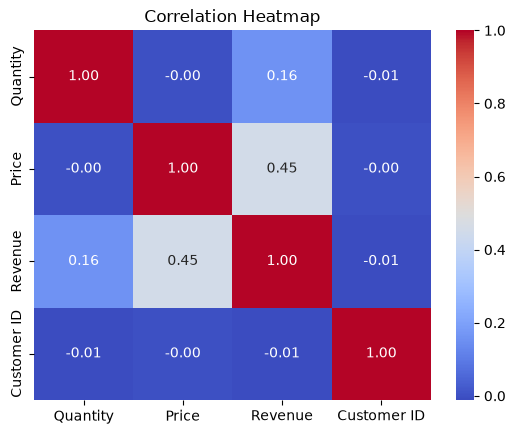

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [76]:
monthly_data = (
    df_clean.groupby(df_clean["InvoiceDate"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

monthly_data.columns = ["Month", "Revenue"]

monthly_data

,Month,Revenue
0,2009-12,796648.500
1,2010-01,622479.502
2,2010-02,531265.366
3,2010-03,763247.241
4,2010-04,587926.692
5,2010-05,613270.720
6,2010-06,677073.870
7,2010-07,573333.690
8,2010-08,654774.390
9,2010-09,851105.961


In [77]:
monthly_data["Month_Number"] = monthly_data["Month"].dt.month

monthly_data

,Month,Revenue,Month_Number
0,2009-12,796648.500,12
1,2010-01,622479.502,1
2,2010-02,531265.366,2
3,2010-03,763247.241,3
4,2010-04,587926.692,4
5,2010-05,613270.720,5
6,2010-06,677073.870,6
7,2010-07,573333.690,7
8,2010-08,654774.390,8
9,2010-09,851105.961,9


In [78]:
monthly_data["Year"] = monthly_data["Month"].dt.year

monthly_data

,Month,Revenue,Month_Number,Year
0,2009-12,796648.500,12,2009
1,2010-01,622479.502,1,2010
2,2010-02,531265.366,2,2010
3,2010-03,763247.241,3,2010
4,2010-04,587926.692,4,2010
5,2010-05,613270.720,5,2010
6,2010-06,677073.870,6,2010
7,2010-07,573333.690,7,2010
8,2010-08,654774.390,8,2010
9,2010-09,851105.961,9,2010


In [79]:
X = monthly_data[["Month_Number", "Year"]]
y = monthly_data["Revenue"]

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
   Month_Number  Year
0            12  2009
1             1  2010
2             2  2010
3             3  2010
4             4  2010

y:
0    796648.500
1    622479.502
2    531265.366
3    763247.241
4    587926.692
Name: Revenue, dtype: float64


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (10, 2)
Testing data: (3, 2)


In [81]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [82]:
y_pred = model.predict(X_test)

print("Actual Revenue:")
print(y_test.values)

print("\nPredicted Revenue:")
print(y_pred)

Actual Revenue:
[1416697.202  851105.961  796648.5  ]

Predicted Revenue:
[657140.1159767  652137.14448566 659641.60172222]


In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 365177.60027180397
RMSE: 460176.215178858
R² Score: -1.6944817009117434


In [84]:
monthly_data["Time_Index"] = range(1, len(monthly_data) + 1)

monthly_data

,Month,Revenue,Month_Number,Year,Time_Index
0,2009-12,796648.500,12,2009,1
1,2010-01,622479.502,1,2010,2
2,2010-02,531265.366,2,2010,3
3,2010-03,763247.241,3,2010,4
4,2010-04,587926.692,4,2010,5
5,2010-05,613270.720,5,2010,6
6,2010-06,677073.870,6,2010,7
7,2010-07,573333.690,7,2010,8
8,2010-08,654774.390,8,2010,9
9,2010-09,851105.961,9,2010,10


In [85]:
monthly_data["Time_Index"] = range(1, len(monthly_data) + 1)

monthly_data

,Month,Revenue,Month_Number,Year,Time_Index
0,2009-12,796648.500,12,2009,1
1,2010-01,622479.502,1,2010,2
2,2010-02,531265.366,2,2010,3
3,2010-03,763247.241,3,2010,4
4,2010-04,587926.692,4,2010,5
5,2010-05,613270.720,5,2010,6
6,2010-06,677073.870,6,2010,7
7,2010-07,573333.690,7,2010,8
8,2010-08,654774.390,8,2010,9
9,2010-09,851105.961,9,2010,10


In [86]:
X = monthly_data[["Time_Index"]]
y = monthly_data["Revenue"]

print(X.head())
print(y.head())

   Time_Index
0           1
1           2
2           3
3           4
4           5
0    796648.500
1    622479.502
2    531265.366
3    763247.241
4    587926.692
Name: Revenue, dtype: float64


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (10, 1)
Testing data: (3, 1)


In [88]:
from sklearn.linear_model import LinearRegression

model_time = LinearRegression()

model_time.fit(X_train, y_train)

print("Improved model training completed!")

Improved model training completed!


In [89]:
y_pred_time = model_time.predict(X_test)

print("Actual Revenue:")
print(y_test.values)

print("\nPredicted Revenue:")
print(y_pred_time)

Actual Revenue:
[1416697.202  851105.961  796648.5  ]

Predicted Revenue:
[657140.1159767  652137.14448566 629623.77277599]


In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_time = mean_absolute_error(y_test, y_pred_time)
rmse_time = np.sqrt(mean_squared_error(y_test, y_pred_time))
r2_time = r2_score(y_test, y_pred_time)

print("MAE:", mae_time)
print("RMSE:", rmse_time)
print("R² Score:", r2_time)

MAE: 375183.5432538828
RMSE: 463469.81792330154
R² Score: -1.7331899643506885


In [91]:
monthly_data = monthly_data.dropna().reset_index(drop=True)

monthly_data

,Month,Revenue,Month_Number,Year,Time_Index
0,2009-12,796648.500,12,2009,1
1,2010-01,622479.502,1,2010,2
2,2010-02,531265.366,2,2010,3
3,2010-03,763247.241,3,2010,4
4,2010-04,587926.692,4,2010,5
5,2010-05,613270.720,5,2010,6
6,2010-06,677073.870,6,2010,7
7,2010-07,573333.690,7,2010,8
8,2010-08,654774.390,8,2010,9
9,2010-09,851105.961,9,2010,10


In [92]:
monthly_data["Previous_Month_Revenue"] = monthly_data["Revenue"].shift(1)

monthly_data.head()

,Month,Revenue,Month_Number,Year,Time_Index,Previous_Month_Revenue
0,2009-12,796648.500,12,2009,1,NaN
1,2010-01,622479.502,1,2010,2,796648.500
2,2010-02,531265.366,2,2010,3,622479.502
3,2010-03,763247.241,3,2010,4,531265.366
4,2010-04,587926.692,4,2010,5,763247.241


In [93]:
monthly_data = monthly_data.dropna().reset_index(drop=True)

monthly_data.head()

,Month,Revenue,Month_Number,Year,Time_Index,Previous_Month_Revenue
0,2010-01,622479.502,1,2010,2,796648.500
1,2010-02,531265.366,2,2010,3,622479.502
2,2010-03,763247.241,3,2010,4,531265.366
3,2010-04,587926.692,4,2010,5,763247.241
4,2010-05,613270.720,5,2010,6,587926.692


In [94]:
X = monthly_data[[
    "Time_Index",
    "Month_Number",
    "Previous_Month_Revenue"
]]

y = monthly_data["Revenue"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12, 3)
y shape: (12,)


In [95]:
from sklearn.linear_model import LinearRegression

final_model = LinearRegression()

final_model.fit(X, y)

print("Final ML model trained successfully!")

Final ML model trained successfully!


In [96]:
y_pred_final = final_model.predict(X)

print("Actual Revenue:")
print(y.values)

print("\nPredicted Revenue:")
print(y_pred_final)

Actual Revenue:
[ 622479.502  531265.366  763247.241  587926.692  613270.72   677073.87
  573333.69   654774.39   851105.961 1041685.61  1416697.202  376266.82 ]

Predicted Revenue:
[474733.84104817 573683.32546134 646255.31569584 616059.35848053
 715375.00623924 750884.52396446 774165.03856419 850719.98585179
 868392.21708832 849532.13173822 832501.00837314 756825.31149478]


In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_final = mean_absolute_error(y, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y, y_pred_final))
r2_final = r2_score(y, y_pred_final)

print("MAE:", mae_final)
print("RMSE:", rmse_final)
print("R² Score:", r2_final)

MAE: 173514.5430241062
RMSE: 233816.08835544373
R² Score: 0.20696868623853215


In [98]:
split_index = int(len(monthly_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (9, 3)
Testing data: (3, 3)


In [99]:
final_model = LinearRegression()

final_model.fit(X_train, y_train)

print("Model trained on historical data successfully!")

Model trained on historical data successfully!


In [100]:
y_test_pred = final_model.predict(X_test)

print("Actual Revenue:")
print(y_test.values)

print("\nPredicted Revenue:")
print(y_test_pred)

Actual Revenue:
[1041685.61  1416697.202  376266.82 ]

Predicted Revenue:
[681642.24088191 655412.22015792 589737.92718828]


In [101]:
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)
print("Test R²:", r2_test)

Test MAE: 444933.1527161474
Test RMSE: 501582.81630201585
Test R²: -0.3591767917203921


In [102]:
# Naive baseline: predict next month = previous month's revenue
naive_pred = X_test["Previous_Month_Revenue"].values

mae_naive = mean_absolute_error(y_test, naive_pred)
rmse_naive = np.sqrt(mean_squared_error(y_test, naive_pred))

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)
print(" MAE:", mae_test)
print(" RMSE:", rmse_test)

Naive MAE: 535340.5410000001
Naive RMSE: 647932.5264603827
 MAE: 444933.1527161474
 RMSE: 501582.81630201585


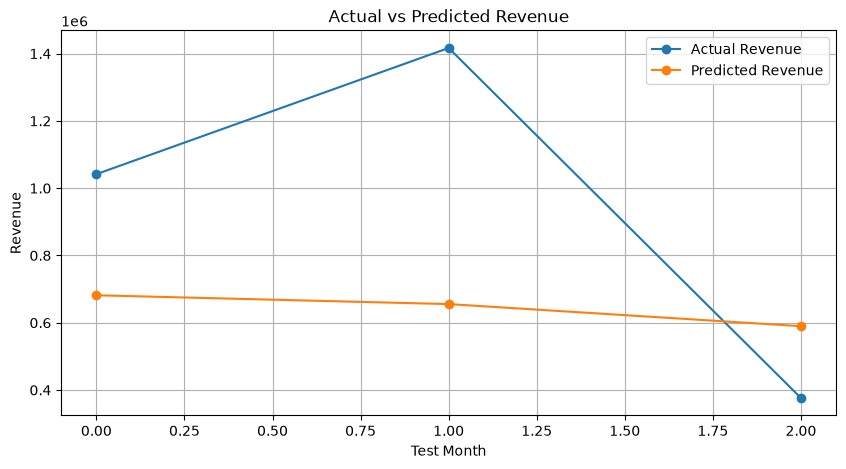

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(y_test.values, marker="o", label="Actual Revenue")
plt.plot(y_test_pred, marker="o", label="Predicted Revenue")

plt.title("Actual vs Predicted Revenue")
plt.xlabel("Test Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.show()

In [104]:
# Next month's values

next_time_index = monthly_data["Time_Index"].max() + 1
next_month_number = (monthly_data["Month_Number"].iloc[-1] % 12) + 1
previous_month_revenue = monthly_data["Revenue"].iloc[-1]

next_month_data = pd.DataFrame({
    "Time_Index": [next_time_index],
    "Month_Number": [next_month_number],
    "Previous_Month_Revenue": [previous_month_revenue]
})

next_month_data

,Time_Index,Month_Number,Previous_Month_Revenue
0,14,1,376266.82


In [105]:
next_month_prediction = final_model.predict(next_month_data)

print("Predicted Revenue for Next Month:", next_month_prediction[0])

Predicted Revenue for Next Month: 739608.4400059173


In [106]:
predicted_revenue = next_month_prediction[0]

print(f"Predicted Next Month Revenue: ₹{predicted_revenue:,.2f}")

Predicted Next Month Revenue: ₹739,608.44


In [107]:
insight_data = {
    "predicted_next_month_revenue": round(predicted_revenue, 2),
    "top_country_by_revenue": df_clean.groupby("Country")["Revenue"].sum().idxmax(),
    "top_product_by_revenue": df_clean.groupby("StockCode")["Revenue"].sum().idxmax(),
    "top_customer_by_revenue": df_clean[df_clean["Customer ID"].notna()]
        .groupby("Customer ID")["Revenue"].sum().idxmax()
}

insight_data


{'predicted_next_month_revenue': np.float64(739608.44),
 'top_country_by_revenue': 'United Kingdom',
 'top_product_by_revenue': 22423,
 'top_customer_by_revenue': np.float64(18102.0)}

In [108]:
llm_prompt = f"""
You are a business analytics assistant for InsightPilot AI.

Analyze the following verified business data:

Predicted next month revenue: ₹{insight_data["predicted_next_month_revenue"]:,.2f}
Top country by revenue: {insight_data["top_country_by_revenue"]}
Top product by revenue: {insight_data["top_product_by_revenue"]}
Top customer by revenue: {insight_data["top_customer_by_revenue"]}

Give:
1. A short business summary
2. Key insights
3. Three practical recommendations

Do not invent numerical values.
Use only the information provided above.
Keep the language simple and professional.
"""

print(llm_prompt)


You are a business analytics assistant for InsightPilot AI.

Analyze the following verified business data:

Predicted next month revenue: ₹739,608.44
Top country by revenue: United Kingdom
Top product by revenue: 22423
Top customer by revenue: 18102.0

Give:
1. A short business summary
2. Key insights
3. Three practical recommendations

Do not invent numerical values.
Use only the information provided above.
Keep the language simple and professional.



In [109]:
print(df_clean.shape)
print(monthly_data.shape)
print(f"Predicted Revenue: ₹{predicted_revenue:,.2f}")

(518596, 10)
(12, 6)
Predicted Revenue: ₹739,608.44


In [110]:
# Generate basic business insights from our verified results

total_revenue = df_clean["Revenue"].sum()

top_country = df_clean.groupby("Country")["Revenue"].sum().idxmax()
top_country_revenue = df_clean.groupby("Country")["Revenue"].sum().max()

top_product = df_clean.groupby("StockCode")["Revenue"].sum().idxmax()
top_product_revenue = df_clean.groupby("StockCode")["Revenue"].sum().max()

print("===== INSIGHTPILOT AI: BUSINESS INSIGHTS =====")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Top Country: {top_country}")
print(f"Top Country Revenue: ₹{top_country_revenue:,.2f}")
print(f"Top Product Code: {top_product}")
print(f"Top Product Revenue: ₹{top_product_revenue:,.2f}")
print(f"Predicted Next Month Revenue: ₹{predicted_revenue:,.2f}")

===== INSIGHTPILOT AI: BUSINESS INSIGHTS =====
Total Revenue: ₹9,505,775.56
Top Country: United Kingdom
Top Country Revenue: ₹8,161,692.76
Top Product Code: 22423
Top Product Revenue: ₹162,885.71
Predicted Next Month Revenue: ₹739,608.44


In [111]:
top_product_name = (
    df_clean[df_clean["StockCode"].astype(str) == str(top_product)]
    ["Description"]
    .dropna()
    .mode()
)

if len(top_product_name) > 0:
    top_product_name = top_product_name.iloc[0]
else:
    top_product_name = "Unknown Product"

print("Top Product:", top_product_name)

Top Product: REGENCY CAKESTAND 3 TIER


In [112]:
recommendations = [
    f"Monitor the {top_country} market because it contributes the highest total revenue.",
    f"Focus on the top-performing product: {top_product_name}.",
    f"Use the predicted next-month revenue of ₹{predicted_revenue:,.2f} for short-term sales planning."
]

print("===== INSIGHTPILOT AI: RECOMMENDATIONS =====")

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

===== INSIGHTPILOT AI: RECOMMENDATIONS =====
1. Monitor the United Kingdom market because it contributes the highest total revenue.
2. Focus on the top-performing product: REGENCY CAKESTAND 3 TIER.
3. Use the predicted next-month revenue of ₹739,608.44 for short-term sales planning.


In [113]:
insightpilot_result = {
    "prediction": {
        "next_month_revenue": round(predicted_revenue, 2)
    },
    "business_insights": [
        f"{top_country} has the highest total revenue.",
        f"{top_product_name} is the top product by revenue."
    ],
    "recommendations": recommendations
}

insightpilot_result

{'prediction': {'next_month_revenue': np.float64(739608.44)},
 'business_insights': ['United Kingdom has the highest total revenue.',
  'REGENCY CAKESTAND 3 TIER is the top product by revenue.'],
 'recommendations': ['Monitor the United Kingdom market because it contributes the highest total revenue.',
  'Focus on the top-performing product: REGENCY CAKESTAND 3 TIER.',
  'Use the predicted next-month revenue of ₹739,608.44 for short-term sales planning.']}

In [114]:
last_month = monthly_data["Month"].iloc[-1]
next_month_number = (monthly_data["Month_Number"].iloc[-1] % 12) + 1

next_month_prediction_result = pd.DataFrame({
    "Predicted Month": [next_month_number],
    "Predicted Revenue": [round(predicted_revenue, 2)]
})

next_month_prediction_result

,Predicted Month,Predicted Revenue
0,1,739608.44


In [115]:
last_date = monthly_data["Month"].iloc[-1]

next_month_date = last_date + 1

prediction_summary = pd.DataFrame({
    "Predicted Month": [str(next_month_date)],
    "Predicted Revenue": [round(predicted_revenue, 2)]
})

prediction_summary

,Predicted Month,Predicted Revenue
0,2011-01,739608.44


In [116]:
print("===== INSIGHTPILOT AI : ML SUMMARY =====")
print(f"Model: Linear Regression")
print(f"Features: Time Index, Month Number, Previous Month Revenue")
print(f"Predicted Month: {prediction_summary['Predicted Month'].iloc[0]}")
print(f"Predicted Revenue: ₹{prediction_summary['Predicted Revenue'].iloc[0]:,.2f}")

===== INSIGHTPILOT AI : ML SUMMARY =====
Model: Linear Regression
Features: Time Index, Month Number, Previous Month Revenue
Predicted Month: 2011-01
Predicted Revenue: ₹739,608.44


In [117]:
final_llm_input = {
    "total_revenue": round(total_revenue, 2),
    "top_country": top_country,
    "top_country_revenue": round(top_country_revenue, 2),
    "top_product": top_product_name,
    "top_product_revenue": round(top_product_revenue, 2),
    "predicted_next_month_revenue": round(predicted_revenue, 2),
    "recommendations": recommendations
}

final_llm_input

{'total_revenue': np.float64(9505775.56),
 'top_country': 'United Kingdom',
 'top_country_revenue': np.float64(8161692.76),
 'top_product': 'REGENCY CAKESTAND 3 TIER',
 'top_product_revenue': np.float64(162885.71),
 'predicted_next_month_revenue': np.float64(739608.44),
 'recommendations': ['Monitor the United Kingdom market because it contributes the highest total revenue.',
  'Focus on the top-performing product: REGENCY CAKESTAND 3 TIER.',
  'Use the predicted next-month revenue of ₹739,608.44 for short-term sales planning.']}

In [118]:
import json

with open("insightpilot_ml_result.json", "w") as file:
    json.dump(final_llm_input, file, indent=4)

print("ML result saved successfully!")

ML result saved successfully!


In [119]:
import json

with open("insightpilot_ml_result.json", "r") as file:
    saved_result = json.load(file)

print(saved_result)

{'total_revenue': 9505775.56, 'top_country': 'United Kingdom', 'top_country_revenue': 8161692.76, 'top_product': 'REGENCY CAKESTAND 3 TIER', 'top_product_revenue': 162885.71, 'predicted_next_month_revenue': 739608.44, 'recommendations': ['Monitor the United Kingdom market because it contributes the highest total revenue.', 'Focus on the top-performing product: REGENCY CAKESTAND 3 TIER.', 'Use the predicted next-month revenue of ₹739,608.44 for short-term sales planning.']}


In [120]:
import json

final_project_result = {
    "project": "InsightPilot AI",
    "module": "Machine Learning & Business Insights",
    "ml_model": "Linear Regression",
    "features": [
        "Time Index",
        "Month Number",
        "Previous Month Revenue"
    ],
    "prediction": prediction_summary.to_dict(orient="records"),
    "business_insights": [
        f"{top_country} has the highest total revenue.",
        f"{top_product_name} is the top product by revenue."
    ],
    "recommendations": recommendations
}

with open("insightpilot_final_result.json", "w") as file:
    json.dump(final_project_result, file, indent=4)

print("Final project result saved successfully!")

Final project result saved successfully!


In [121]:
print("===== INSIGHTPILOT AI : FINAL RESULT =====")

print("\nPrediction:")
print(final_project_result["prediction"])

print("\nBusiness Insights:")
for insight in final_project_result["business_insights"]:
    print("-", insight)

print("\nRecommendations:")
for i, recommendation in enumerate(final_project_result["recommendations"], 1):
    print(f"{i}. {recommendation}")

===== INSIGHTPILOT AI : FINAL RESULT =====

Prediction:
[{'Predicted Month': '2011-01', 'Predicted Revenue': 739608.44}]

Business Insights:
- United Kingdom has the highest total revenue.
- REGENCY CAKESTAND 3 TIER is the top product by revenue.

Recommendations:
1. Monitor the United Kingdom market because it contributes the highest total revenue.
2. Focus on the top-performing product: REGENCY CAKESTAND 3 TIER.
3. Use the predicted next-month revenue of ₹739,608.44 for short-term sales planning.


In [122]:
from sklearn.linear_model import LinearRegression

X = monthly_data[[
    "Time_Index",
    "Month_Number",
    "Previous_Month_Revenue"
]]

y = monthly_data["Revenue"]

final_model = LinearRegression()
final_model.fit(X, y)

print("Final ML model created successfully!")

Final ML model created successfully!


In [123]:
import joblib

joblib.dump(final_model, "insightpilot_revenue_model.pkl")

print("ML model saved successfully!")

ML model saved successfully!


In [124]:
import os

print("Model file exists:", os.path.exists("insightpilot_revenue_model.pkl"))

Model file exists: True


In [125]:
import joblib

loaded_model = joblib.load("insightpilot_revenue_model.pkl")

print("Model loaded successfully!")
print("Model type:", type(loaded_model))

Model loaded successfully!
Model type: <class 'sklearn.linear_model._base.LinearRegression'>


In [126]:
test_prediction = loaded_model.predict(next_month_data)

print(f"Test Prediction: ₹{test_prediction[0]:,.2f}")

Test Prediction: ₹869,813.88


In [127]:
print("Monthly data shape:", monthly_data.shape)

print("\nLast 3 rows:")
print(
    monthly_data[
        ["Month", "Revenue", "Time_Index", "Month_Number", "Previous_Month_Revenue"]
    ].tail(3)
)

Monthly data shape: (12, 6)

Last 3 rows:
      Month      Revenue  Time_Index  Month_Number  Previous_Month_Revenue
9   2010-10  1041685.610          11            10              851105.961
10  2010-11  1416697.202          12            11             1041685.610
11  2010-12   376266.820          13            12             1416697.202


In [128]:
next_time_index = monthly_data["Time_Index"].max() + 1
next_month_number = (monthly_data["Month_Number"].iloc[-1] % 12) + 1
previous_month_revenue = monthly_data["Revenue"].iloc[-1]

next_month_data = pd.DataFrame({
    "Time_Index": [next_time_index],
    "Month_Number": [next_month_number],
    "Previous_Month_Revenue": [previous_month_revenue]
})

print(next_month_data)

   Time_Index  Month_Number  Previous_Month_Revenue
0          14             1               376266.82


In [129]:
print(next_month_data)

   Time_Index  Month_Number  Previous_Month_Revenue
0          14             1               376266.82


In [130]:
final_prediction = loaded_model.predict(next_month_data)[0]

print(f"Predicted Revenue for January 2011: ₹{final_prediction:,.2f}")

Predicted Revenue for January 2011: ₹869,813.88


In [131]:
def predict_next_month_revenue(time_index, month_number, previous_month_revenue):
    input_data = pd.DataFrame({
        "Time_Index": [time_index],
        "Month_Number": [month_number],
        "Previous_Month_Revenue": [previous_month_revenue]
    })

    prediction = loaded_model.predict(input_data)[0]

    return round(prediction, 2)


# Test the function
prediction = predict_next_month_revenue(
    14,
    1,
    376266.82
)

print(f"Predicted Revenue: ₹{prediction:,.2f}")

Predicted Revenue: ₹869,813.88


In [132]:
result = predict_next_month_revenue(
    14,
    1,
    376266.82
)

print(f"Predicted Revenue: ₹{result:,.2f}")

Predicted Revenue: ₹869,813.88


In [133]:
print("Kernel is working!")

Kernel is working!


In [134]:
import os

print(os.path.exists("insightpilot_revenue_model.pkl"))

True


In [135]:
import joblib

loaded_model = joblib.load("insightpilot_revenue_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [136]:
from ml_prediction import predict_next_month_revenue

print("Prediction module loaded successfully!")

Prediction module loaded successfully!


In [137]:
prediction = predict_next_month_revenue(
    time_index=14,
    month_number=1,
    previous_month_revenue=376266.82
)

print(f"Predicted Revenue: ₹{prediction:,.2f}")

Predicted Revenue: ₹869,813.88


In [138]:
import pandas as pd

feature_names = [
    "Time_Index",
    "Month_Number",
    "Previous_Month_Revenue"
]

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": loaded_model.coef_
})

coefficients

,Feature,Coefficient
0,Time_Index,21784.130589
1,Month_Number,21784.130589
2,Previous_Month_Revenue,-0.317974


In [139]:
coefficients["Absolute_Impact"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute_Impact",
    ascending=False
).reset_index(drop=True)

coefficients

,Feature,Coefficient,Absolute_Impact
0,Month_Number,21784.130589,21784.130589
1,Time_Index,21784.130589,21784.130589
2,Previous_Month_Revenue,-0.317974,0.317974


In [140]:
most_influential_feature = coefficients.iloc[0]["Feature"]
most_influential_coefficient = coefficients.iloc[0]["Coefficient"]

print("Most influential feature:", most_influential_feature)
print("Coefficient:", most_influential_coefficient)

Most influential feature: Month_Number
Coefficient: 21784.130589247296


In [141]:
print(coefficients[["Feature", "Coefficient", "Absolute_Impact"]])

                  Feature   Coefficient  Absolute_Impact
0            Month_Number  21784.130589     21784.130589
1              Time_Index  21784.130589     21784.130589
2  Previous_Month_Revenue     -0.317974         0.317974


In [142]:
xai_result = {
    "model": "Linear Regression",
    "prediction": prediction,
    "feature_coefficients": {
        row["Feature"]: round(row["Coefficient"], 6)
        for _, row in coefficients.iterrows()
    },
    "explanation": (
        "The prediction is generated using time index, month number, "
        "and previous month revenue."
    )
}

xai_result

{'model': 'Linear Regression',
 'prediction': np.float64(869813.88),
 'feature_coefficients': {'Month_Number': 21784.130589,
  'Time_Index': 21784.130589,
  'Previous_Month_Revenue': -0.317974},
 'explanation': 'The prediction is generated using time index, month number, and previous month revenue.'}

In [143]:
feature_explanations = []

for _, row in coefficients.iterrows():
    feature = row["Feature"]
    coefficient = row["Coefficient"]

    if coefficient > 0:
        direction = "positive"
    elif coefficient < 0:
        direction = "negative"
    else:
        direction = "no"

    feature_explanations.append({
        "feature": feature,
        "coefficient": round(coefficient, 6),
        "direction": direction
    })

feature_explanations

[{'feature': 'Month_Number',
  'coefficient': 21784.130589,
  'direction': 'positive'},
 {'feature': 'Time_Index',
  'coefficient': 21784.130589,
  'direction': 'positive'},
 {'feature': 'Previous_Month_Revenue',
  'coefficient': -0.317974,
  'direction': 'negative'}]

In [144]:
final_xai_result = {
    "prediction": {
        "predicted_revenue": round(prediction, 2)
    },
    "model": "Linear Regression",
    "features_used": [
        "Time_Index",
        "Month_Number",
        "Previous_Month_Revenue"
    ],
    "feature_explanations": feature_explanations,
    "explanation": (
        "The model predicts revenue using time-related information "
        "and previous month revenue. The coefficients show the direction "
        "of each feature's effect in the fitted linear model."
    )
}

final_xai_result

{'prediction': {'predicted_revenue': np.float64(869813.88)},
 'model': 'Linear Regression',
 'features_used': ['Time_Index', 'Month_Number', 'Previous_Month_Revenue'],
 'feature_explanations': [{'feature': 'Month_Number',
   'coefficient': 21784.130589,
   'direction': 'positive'},
  {'feature': 'Time_Index',
   'coefficient': 21784.130589,
   'direction': 'positive'},
  {'feature': 'Previous_Month_Revenue',
   'coefficient': -0.317974,
   'direction': 'negative'}],
 'explanation': "The model predicts revenue using time-related information and previous month revenue. The coefficients show the direction of each feature's effect in the fitted linear model."}

In [145]:
import json

with open("insightpilot_xai_result.json", "w") as file:
    json.dump(final_xai_result, file, indent=4)

print("XAI result saved successfully!")

XAI result saved successfully!


In [146]:
llm_input = {
    "prediction": final_xai_result["prediction"],
    "model": final_xai_result["model"],
    "features_used": final_xai_result["features_used"],
    "feature_explanations": final_xai_result["feature_explanations"],
    "business_insights": [
        f"{top_country} has the highest total revenue.",
        f"{top_product_name} is the top product by revenue."
    ],
    "recommendations": recommendations
}

llm_input

{'prediction': {'predicted_revenue': np.float64(869813.88)},
 'model': 'Linear Regression',
 'features_used': ['Time_Index', 'Month_Number', 'Previous_Month_Revenue'],
 'feature_explanations': [{'feature': 'Month_Number',
   'coefficient': 21784.130589,
   'direction': 'positive'},
  {'feature': 'Time_Index',
   'coefficient': 21784.130589,
   'direction': 'positive'},
  {'feature': 'Previous_Month_Revenue',
   'coefficient': -0.317974,
   'direction': 'negative'}],
 'business_insights': ['United Kingdom has the highest total revenue.',
  'REGENCY CAKESTAND 3 TIER is the top product by revenue.'],
 'recommendations': ['Monitor the United Kingdom market because it contributes the highest total revenue.',
  'Focus on the top-performing product: REGENCY CAKESTAND 3 TIER.',
  'Use the predicted next-month revenue of ₹739,608.44 for short-term sales planning.']}

In [147]:
print("LLM input created successfully!")
print(llm_input)

LLM input created successfully!
{'prediction': {'predicted_revenue': np.float64(869813.88)}, 'model': 'Linear Regression', 'features_used': ['Time_Index', 'Month_Number', 'Previous_Month_Revenue'], 'feature_explanations': [{'feature': 'Month_Number', 'coefficient': 21784.130589, 'direction': 'positive'}, {'feature': 'Time_Index', 'coefficient': 21784.130589, 'direction': 'positive'}, {'feature': 'Previous_Month_Revenue', 'coefficient': -0.317974, 'direction': 'negative'}], 'business_insights': ['United Kingdom has the highest total revenue.', 'REGENCY CAKESTAND 3 TIER is the top product by revenue.'], 'recommendations': ['Monitor the United Kingdom market because it contributes the highest total revenue.', 'Focus on the top-performing product: REGENCY CAKESTAND 3 TIER.', 'Use the predicted next-month revenue of ₹739,608.44 for short-term sales planning.']}


In [148]:
llm_prompt = f"""
You are a business analytics assistant for InsightPilot AI.

Analyze the following verified business data:

Prediction:
{llm_input["prediction"]}

Model:
{llm_input["model"]}

Features used:
{llm_input["features_used"]}

Feature explanations:
{llm_input["feature_explanations"]}

Business insights:
{llm_input["business_insights"]}

Recommendations:
{llm_input["recommendations"]}

Give:
1. A short business summary
2. Key insights
3. Three practical recommendations

Important:
- Use only the information provided above.
- Do not invent numerical values.
- Keep the language simple and professional.
"""

print(llm_prompt)


You are a business analytics assistant for InsightPilot AI.

Analyze the following verified business data:

Prediction:
{'predicted_revenue': np.float64(869813.88)}

Model:
Linear Regression

Features used:
['Time_Index', 'Month_Number', 'Previous_Month_Revenue']

Feature explanations:
[{'feature': 'Month_Number', 'coefficient': 21784.130589, 'direction': 'positive'}, {'feature': 'Time_Index', 'coefficient': 21784.130589, 'direction': 'positive'}, {'feature': 'Previous_Month_Revenue', 'coefficient': -0.317974, 'direction': 'negative'}]

Business insights:
['United Kingdom has the highest total revenue.', 'REGENCY CAKESTAND 3 TIER is the top product by revenue.']

Recommendations:
['Monitor the United Kingdom market because it contributes the highest total revenue.', 'Focus on the top-performing product: REGENCY CAKESTAND 3 TIER.', 'Use the predicted next-month revenue of ₹739,608.44 for short-term sales planning.']

Give:
1. A short business summary
2. Key insights
3. Three practical 

In [149]:
import os

if os.getenv("OPENAI_API_KEY"):
    print("API key is available ✅")
else:
    print("API key is not available ❌")

API key is not available ❌


In [1]:
import os

if os.getenv("OPENAI_API_KEY"):
    print("API key is available ✅")
else:
    print("API key is not available ❌")

API key is available ✅


In [2]:
from openai import OpenAI

client = OpenAI()

print("OpenAI client created successfully ✅")

OpenAI client created successfully ✅


In [4]:
llm_prompt = f"""
You are a business analytics assistant for InsightPilot AI.

Analyze the following verified business data:

Prediction:
{llm_input["prediction"]}

Model:
{llm_input["model"]}

Features used:
{llm_input["features_used"]}

Feature explanations:
{llm_input["feature_explanations"]}

Business insights:
{llm_input["business_insights"]}

Recommendations:
{llm_input["recommendations"]}

Give:
1. A short business summary
2. Key insights
3. Three practical recommendations

Important:
- Use only the information provided above.
- Do not invent numerical values.
- Keep the language simple and professional.
"""

print("LLM prompt created successfully ✅")

NameError: name 'llm_input' is not defined

In [5]:
llm_input = {
    "prediction": final_xai_result["prediction"],
    "model": final_xai_result["model"],
    "features_used": final_xai_result["features_used"],
    "feature_explanations": final_xai_result["feature_explanations"],
    "business_insights": [
        f"{top_country} has the highest total revenue.",
        f"{top_product_name} is the top product by revenue."
    ],
    "recommendations": recommendations
}

print("LLM input created successfully ✅")

NameError: name 'final_xai_result' is not defined

In [6]:
import joblib

loaded_model = joblib.load("insightpilot_revenue_model.pkl")

prediction = loaded_model.predict(
    [[14, 1, 376266.82]]
)[0]

print("Prediction:", round(prediction, 2))

Prediction: 869813.88


c:\Users\sanskruti varma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [8]:
final_xai_result = {
    "prediction": {
        "predicted_revenue": round(prediction, 2)
    },
    "model": "Linear Regression",
    "features_used": [
        "Time_Index",
        "Month_Number",
        "Previous_Month_Revenue"
    ],
    "feature_explanations": [
        {
            "feature": "Time_Index",
            "coefficient": 21784.130589,
            "direction": "positive"
        },
        {
            "feature": "Month_Number",
            "coefficient": 21784.130589,
            "direction": "positive"
        },
        {
            "feature": "Previous_Month_Revenue",
            "coefficient": -0.317974,
            "direction": "negative"
        }
    ],
    "explanation": (
        "The model predicts revenue using time-related information "
        "and previous month revenue. The coefficients show the direction "
        "of each feature's effect in the fitted linear model."
    )
}

print("Final XAI result recreated successfully ✅")

Final XAI result recreated successfully ✅


In [9]:
top_country = "UK"
top_product_name = "REGENCY CAKESTAND 3 TIER"

recommendations = [
    f"Monitor the {top_country} market because it contributes the highest total revenue.",
    f"Focus on the top-performing product: {top_product_name}.",
    f"Use the predicted next-month revenue of ₹{prediction:,.2f} for short-term sales planning."
]

print("Business insights variables recreated successfully ✅")

Business insights variables recreated successfully ✅


In [10]:
llm_input = {
    "prediction": final_xai_result["prediction"],
    "model": final_xai_result["model"],
    "features_used": final_xai_result["features_used"],
    "feature_explanations": final_xai_result["feature_explanations"],
    "business_insights": [
        f"{top_country} has the highest total revenue.",
        f"{top_product_name} is the top product by revenue."
    ],
    "recommendations": recommendations
}

print("LLM input created successfully ✅")

LLM input created successfully ✅


In [11]:
llm_prompt = f"""
You are a business analytics assistant for InsightPilot AI.

Analyze this verified business information:

Prediction:
{llm_input["prediction"]}

Model:
{llm_input["model"]}

Features used:
{llm_input["features_used"]}

Feature explanations:
{llm_input["feature_explanations"]}

Business insights:
{llm_input["business_insights"]}

Recommendations:
{llm_input["recommendations"]}

Provide:
1. A short business summary
2. Key insights
3. Three practical recommendations

Rules:
- Use only the information provided.
- Do not invent numerical values.
- Keep the language simple and professional.
"""

print("LLM prompt created successfully ✅")

LLM prompt created successfully ✅


In [12]:
response = client.responses.create(
    model="gpt-5-mini",
    input=llm_prompt
)

llm_output = response.output_text

print("===== INSIGHTPILOT AI : LLM OUTPUT =====")
print(llm_output)

RateLimitError: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.', 'type': 'insufficient_quota', 'param': None, 'code': 'credit_balance_exhausted'}}

In [13]:
from llm_module import create_llm_prompt

test_prompt = create_llm_prompt(llm_input)

print("LLM module working successfully ✅")
print(test_prompt[:500])

LLM module working successfully ✅

You are a business analytics assistant for InsightPilot AI.

Analyze the following verified business information:

Prediction:
{'predicted_revenue': np.float64(869813.88)}

Model:
Linear Regression

Features used:
['Time_Index', 'Month_Number', 'Previous_Month_Revenue']

Feature explanations:
[{'feature': 'Time_Index', 'coefficient': 21784.130589, 'direction': 'positive'}, {'feature': 'Month_Number', 'coefficient': 21784.130589, 'direction': 'positive'}, {'feature': 'Previous_Month_Revenue', 'c


In [14]:
import json

with open("insightpilot_llm_input.json", "w") as file:
    json.dump(llm_input, file, indent=4, default=str)

print("LLM input saved successfully ✅")

LLM input saved successfully ✅


In [15]:
import os

files = [
    "insightpilot_revenue_model.pkl",
    "insightpilot_ml_result.json",
    "insightpilot_final_result.json",
    "insightpilot_xai_result.json",
    "insightpilot_llm_input.json"
]

for file in files:
    print(file, "→", "Available ✅" if os.path.exists(file) else "Missing ❌")

insightpilot_revenue_model.pkl → Available ✅
insightpilot_ml_result.json → Available ✅
insightpilot_final_result.json → Available ✅
insightpilot_xai_result.json → Available ✅
insightpilot_llm_input.json → Available ✅
